# Printability Comparison Dashboard

**Repository**: matreum/am-solidification-screening | **Notebook 04**

## Purpose

Consolidate all solidification metrics from Notebooks 01–03 into a single comparative
dashboard. This produces the one-page summary table and visualization that an engineer
would use to make a go/no-go decision on alloy selection for a new AM build.

### Alloys Compared

| Alloy | System | Database | Key AM Application |
|-------|--------|----------|--------------------|
| 316L SS | Fe-Cr-Ni-Mo-Mn-Si-C | steel_database_fix.tdb | Corrosion-resistant parts |
| AlSi10Mg | Al-Si-Mg | cost507_corrected.tdb | Lightweight structures |
| IN718 | Ni-Cr-Fe-Nb-Mo-Ti-Al-C | steel_database_fix.tdb | High-temp turbine components |
| Ti-6Al-4V | Ti-Al-V | cost507_corrected.tdb | Aerospace/biomedical |

### What “Printability” Means Here

Printability is not a single number. This dashboard assesses:
1. **Solidification cracking susceptibility** — via three established criteria
2. **Solidification range** — width of the mushy zone
3. **Composite Printability Index (CPI)** — weighted average of normalized metrics

### What This Does NOT Assess
- Melt pool stability (balling, spatter)
- Residual stress or distortion
- Porosity from keyholing or lack-of-fusion
- Post-build microstructure evolution

Those require process simulation and are proprietary service deliverables.

In [1]:
import sys, os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))

from matreum_am_screening.core import (
    run_scheil, ALLOY_316L, ALLOY_ALSI10MG, ALLOY_IN718, ALLOY_TI64,
    kou_index, clyne_davies, rdg_index, printability_summary
)
from matreum_am_screening.plotting import (
    plot_radar, plot_overlaid_scheil, plot_cracking_ranking
)

plt.rcParams['figure.dpi'] = 120
print("Dependencies loaded.")

Dependencies loaded.


In [2]:
# Run Scheil simulations for all four alloys
print("Running Scheil simulations...")

print("  316L SS...")
res_316L = run_scheil(ALLOY_316L)
print(f"    \u0394T = {res_316L.solidification_range_C:.0f} \u00b0C")

print("  AlSi10Mg...")
res_AlSi = run_scheil(ALLOY_ALSI10MG)
print(f"    \u0394T = {res_AlSi.solidification_range_C:.0f} \u00b0C")

print("  IN718...")
res_IN718 = run_scheil(ALLOY_IN718)
print(f"    \u0394T = {res_IN718.solidification_range_C:.0f} \u00b0C")

print("  Ti-6Al-4V...")
res_Ti64 = run_scheil(ALLOY_TI64)
print(f"    \u0394T = {res_Ti64.solidification_range_C:.0f} \u00b0C")

results = {
    "316L SS": res_316L,
    "AlSi10Mg": res_AlSi,
    "IN718": res_IN718,
    "Ti-6Al-4V": res_Ti64,
}
print("\nAll simulations complete.")

Running Scheil simulations...
  316L SS...


    ΔT = 278 °C
  AlSi10Mg...


    ΔT = 37 °C
  IN718...


    ΔT = 495 °C
  Ti-6Al-4V...


    ΔT = 46 °C

All simulations complete.


## Overlaid Solidification Curves

Direct visual comparison of solidification trajectories. Wider curves (larger ΔT)
indicate broader mushy zones and generally higher defect susceptibility.

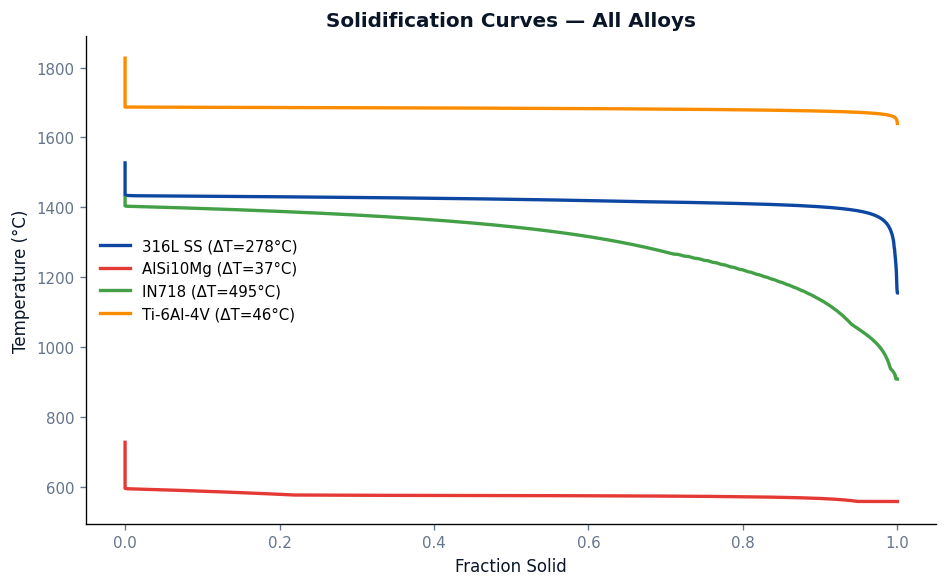

In [3]:
fig = plot_overlaid_scheil(results)
plt.show()

## Raw Metrics Table

In [4]:
df = printability_summary(results)

print("\n" + "=" * 90)
print("RAW SOLIDIFICATION METRICS")
print("=" * 90)
raw_cols = ["alloy", "T_liquidus_C", "T_solidus_C", "delta_T_C", "CSC_Kou", "CSC_CD", "RDG_index"]
print(df[raw_cols].to_string(index=False))


RAW SOLIDIFICATION METRICS
    alloy  T_liquidus_C  T_solidus_C  delta_T_C      CSC_Kou   CSC_CD  RDG_index
  316L SS       1432.85  1154.542408 278.307592  8403.347604 2.517590   2.807359
 AlSi10Mg        593.85   557.254316  36.595684   616.695791 0.999114   0.624549
    IN718       1402.85   907.822860 495.027140 14042.443296 0.832008   1.231363
Ti-6Al-4V       1685.85  1639.850000  46.000000   832.597804 1.372806  13.336396


## Phase Formation Summary

Phases formed during Scheil solidification for each alloy. The formation of
intermetallic phases (Laves, η) at terminal solidification is a key driver of
cracking susceptibility.

In [5]:
for name, res in results.items():
    print(f"\n{name}:")
    print(f"  T_liquidus = {res.T_liquidus_C:.1f} \u00b0C  |  T_solidus = {res.T_solidus_C:.1f} \u00b0C  |  \u0394T = {res.solidification_range_C:.1f} \u00b0C")
    print(f"  Phases formed:")
    for phase, amounts in sorted(res.phase_amounts.items()):
        final_frac = amounts[-1]
        if final_frac > 0.001:
            print(f"    {phase:<20} {final_frac:>8.4f} ({final_frac*100:.1f}%)")


316L SS:
  T_liquidus = 1432.8 °C  |  T_solidus = 1154.5 °C  |  ΔT = 278.3 °C
  Phases formed:
    BCC_A2                 0.7442 (74.4%)
    FCC_A1                 0.2544 (25.4%)
    M23C6                  0.0010 (0.1%)

AlSi10Mg:
  T_liquidus = 593.9 °C  |  T_solidus = 557.3 °C  |  ΔT = 36.6 °C
  Phases formed:
    DIAMOND_A4             0.0850 (8.5%)
    FCC_A1                 0.9113 (91.1%)
    MG2SI                  0.0037 (0.4%)

IN718:
  T_liquidus = 1402.8 °C  |  T_solidus = 907.8 °C  |  ΔT = 495.0 °C
  Phases formed:
    BCC_A2                 0.0089 (0.9%)
    FCC_A1                 0.9008 (90.1%)
    FCC_A1#1               0.0678 (6.8%)
    FCC_A1#2               0.0204 (2.0%)
    LAVES_PHASE            0.0010 (0.1%)

Ti-6Al-4V:
  T_liquidus = 1685.8 °C  |  T_solidus = 1639.8 °C  |  ΔT = 46.0 °C
  Phases formed:
    BCC_A2                 0.9999 (100.0%)


## Radar Chart — Normalized Comparison

Each axis represents one normalized metric (0 = best, 1 = worst). The alloy with the
smallest polygon has the best overall printability by thermodynamic screening.

**Important**: The CPI uses equal weighting of all metrics. For specific applications,
some metrics matter more than others (e.g., for thin-wall features, ΔT matters more;
for large cross-sections, RDG matters more). The individual metrics in the full table
are more informative than any single composite number.

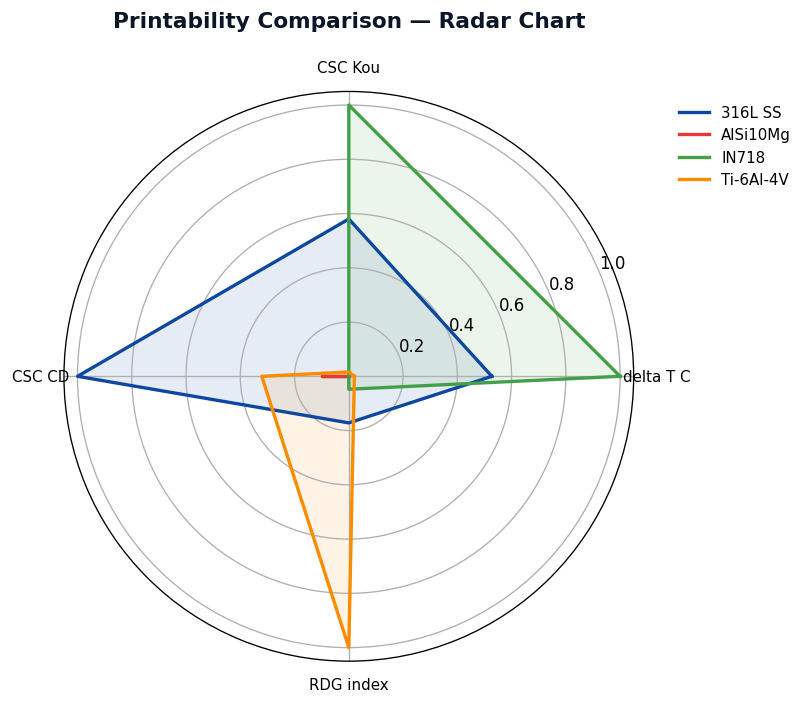

In [6]:
fig = plot_radar(df)
plt.show()

## Cracking Susceptibility Ranking (Bar Chart)

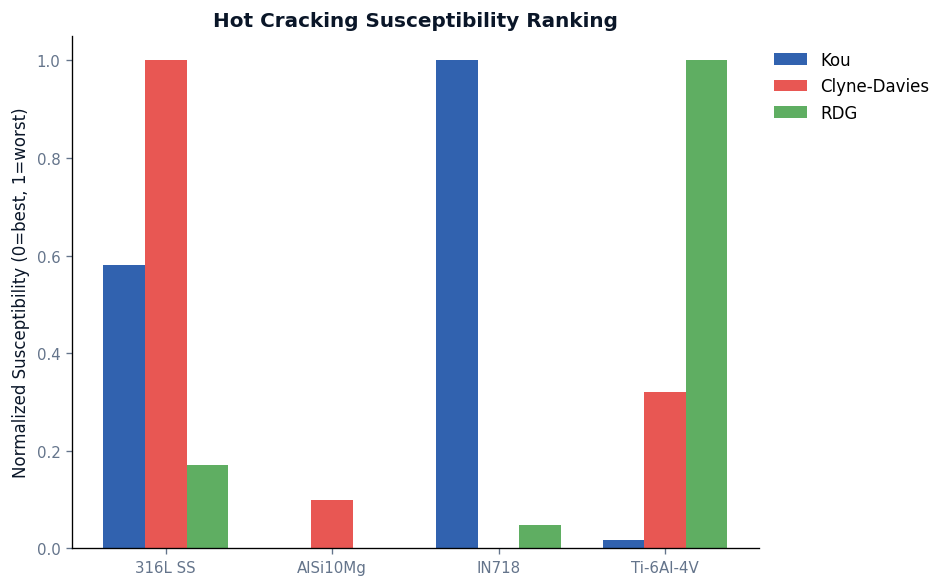

In [7]:
fig = plot_cracking_ranking(df)
plt.show()

## Final Ranking

In [8]:
print("\n" + "=" * 90)
print("PRINTABILITY RANKING \u2014 Composite Printability Index (CPI)")
print("=" * 90)
print("  Lower CPI = better printability (0 = best across all metrics)")
print()
norm_cols = ["alloy", "delta_T_C_norm", "CSC_Kou_norm", "CSC_CD_norm", "RDG_index_norm", "CPI", "Rank"]
print(df[norm_cols].to_string(index=False))
print()
best = df.loc[df["CPI"].idxmin(), "alloy"]
print(f"Best printability by CPI: {best}")
print()
print("DISCLAIMER: CPI is a screening heuristic with equal metric weighting, not a validated")
print("predictive model. The individual metrics above are more informative than the composite.")


PRINTABILITY RANKING — Composite Printability Index (CPI)
  Lower CPI = better printability (0 = best across all metrics)

    alloy  delta_T_C_norm  CSC_Kou_norm  CSC_CD_norm  RDG_index_norm      CPI  Rank
  316L SS        0.527259      0.579979     1.000000        0.171715 0.569738     4
 AlSi10Mg        0.000000      0.000000     0.099138        0.000000 0.024785     1
    IN718        1.000000      1.000000     0.000000        0.047736 0.511934     3
Ti-6Al-4V        0.020514      0.016081     0.320837        1.000000 0.339358     2

Best printability by CPI: AlSi10Mg

DISCLAIMER: CPI is a screening heuristic with equal metric weighting, not a validated
predictive model. The individual metrics above are more informative than the composite.


## Alloy-Specific Discussion

### IN718 (Inconel 718)

IN718 is the most widely used Ni-base superalloy in AM. Its high Nb content
(~5 wt%) drives the formation of Laves phase and NbC eutectic at terminal
solidification, creating a very wide solidification range (~480–500 °C by Scheil).
This makes IN718 highly susceptible to solidification cracking in LPBF, consistent
with the well-documented need for careful parameter optimization and post-build
homogenization heat treatment (1080°C/1h + aging).

**Key observations**:
- Widest solidification range of the four alloys
- Laves phase formation at terminal solidification (Nb-rich eutectic)
- High Kou index driven by steep T vs. f_s curve near f_s → 1
- Commercial LPBF builds routinely require HIP + solution treatment to dissolve Laves

**Database note**: Results use the open-source steel_database_fix.tdb which
includes Ni-Cr-Fe-Nb-Mo interactions. For quantitative predictions, commercial
Ni-base databases (TCNI, TTNi) with validated γ′/γ″ descriptions are recommended.

### Ti-6Al-4V (Grade 5 Titanium)

Ti-6Al-4V is the workhorse Ti alloy for aerospace AM. It solidifies through a
single BCC (β) phase with a narrow solidification range (~40–50 °C), making it
one of the most solidification-crack-resistant alloys in AM. The primary
challenges for Ti-6Al-4V in LPBF are residual stress, columnar β grain
growth, and oxygen pickup — none of which are captured by thermodynamic screening.

**Key observations**:
- Narrow solidification range, comparable to AlSi10Mg
- Single-phase BCC solidification (no secondary phases in mushy zone)
- Low Kou index — minimal susceptibility to solidification cracking
- Real AM challenges are microstructural (columnar β, martensite) not solidification-related

**Database note**: Results use the open-source COST 507 light metals database
which includes Ti-Al-V ternary interactions. For quantitative predictions,
commercial Ti databases (TCTI, PanTi) with validated α/β descriptions are recommended.

## Extending to Additional Alloys

This methodology generalizes to any alloy system with a CALPHAD thermodynamic database:

```python
from matreum_am_screening.core import AlloySystem, run_scheil
from pycalphad import variables as v

my_alloy = AlloySystem(
    name="Custom Alloy",
    components=["FE", "CR", "NI", "VA"],
    phases=["LIQUID", "FCC_A1", "BCC_A2"],
    composition={v.X("CR"): 0.20, v.X("NI"): 0.10},
    db_path="path/to/your/database.tdb",
    start_temperature=1800.0,
)
result = run_scheil(my_alloy)
```

## Stated Limitations

1. **Thermodynamic screening only.** This dashboard does not assess porosity, residual
   stress, distortion, surface roughness, or mechanical properties.

2. **Composite index is a heuristic.** Equal weighting is a convenience, not a physical model.

3. **No experimental validation in this notebook.** Rankings should be compared against
   published AM cracking data.

4. **Open-source databases.** IN718 and Ti-6Al-4V results use general-purpose databases
   (steel_database_fix.tdb, COST 507) rather than alloy-system-specific commercial databases.
   Absolute values should be treated as approximate; relative rankings are more reliable.

5. **No process parameter dependence.** Alloys ranking identically here may behave very
   differently at different power/speed combinations.

---
*Matreum LLC — AM Solidification Screening, 2026*